In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
normal_df = pd.read_csv("C:/B3/ml in med/dataset_lab1/mitbih_test.csv",header=None)
anomaly_df = pd.read_csv("C:/B3/ml in med/dataset_lab1/ptbdb_abnormal.csv",header=None)
train = pd.read_csv("C:/B3/ml in med/dataset_lab1/mitbih_train.csv",header=None)
test =pd.read_csv("C:/B3/ml in med/dataset_lab1/mitbih_test.csv",header=None)

In [3]:
y = train.shape[1] - 1

class_labels = train[y].unique()
class_labels

class_names = {
    0: "N",
    1: "S",
    2: "V",
    3: "F",
    4: "Q"
}

In [4]:
def check_missing_values(df):
    print("\n Missing Values Check")
    missing_summary = df.isnull().sum()
    print("\nMissing values per column:")
    print(missing_summary)
    total_missing = missing_summary.sum()
    print(f"\nTotal missing values in the dataset: {total_missing}")

def check_duplicates(df):
    print("\nChecking for Duplicated Rows")
    duplicate_rows = df[df.duplicated()]
    print(f"Number of duplicate rows: {len(duplicate_rows)}")
    if len(duplicate_rows) > 0:
        print("\nDuplicated rows:")
        print(duplicate_rows)

if train is not None:
        check_missing_values(train)
        check_duplicates(train)


 Missing Values Check

Missing values per column:
0      0
1      0
2      0
3      0
4      0
      ..
183    0
184    0
185    0
186    0
187    0
Length: 188, dtype: int64

Total missing values in the dataset: 0

Checking for Duplicated Rows
Number of duplicate rows: 0


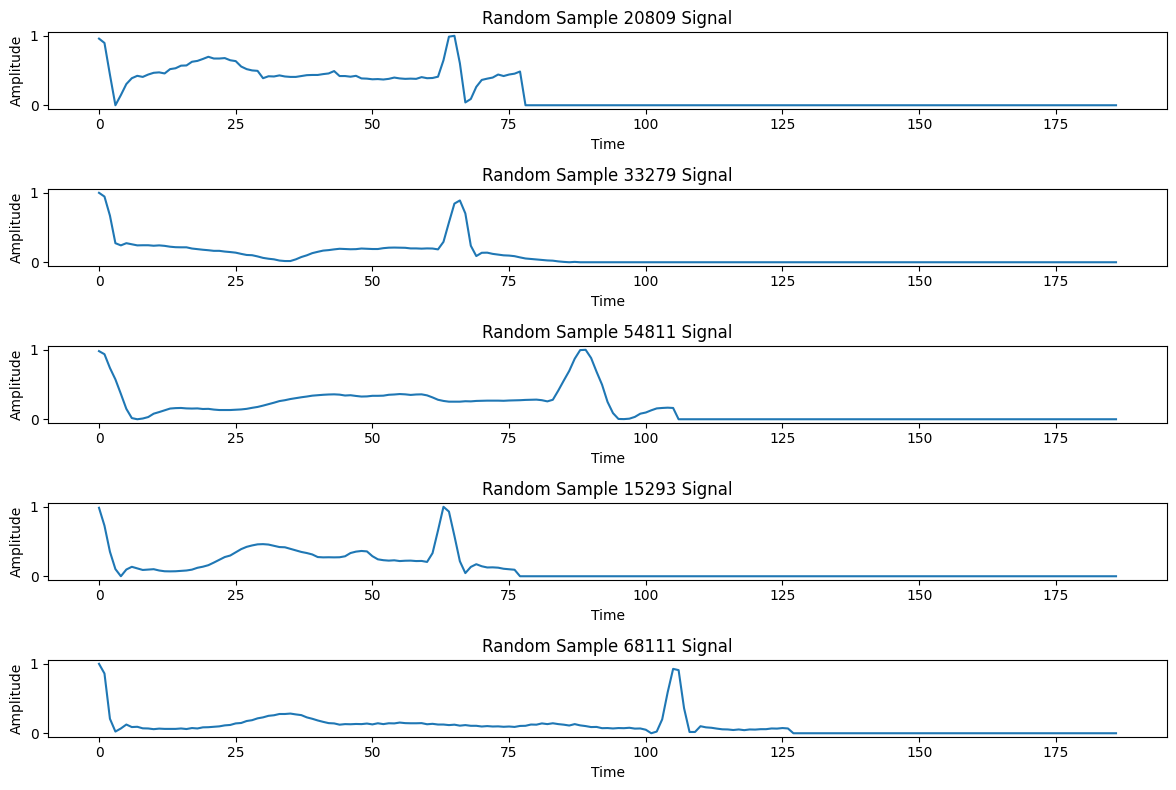

In [5]:
import random
import matplotlib.pyplot as plt

def plot_random_heartbeat_signal(data, num_samples=5):
    indices = random.sample(range(data.shape[0]), num_samples)  # Random indices
    plt.figure(figsize=(12, 8))
    
    for i, idx in enumerate(indices):
        plt.subplot(num_samples, 1, i+1)
        plt.plot(data.iloc[idx, :-1])
        plt.title(f'Random Sample {idx+1} Signal')
        plt.xlabel('Time')
        plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()

plot_random_heartbeat_signal(train, num_samples=5)

In [6]:
train[187]=train[187].astype(float)
equilibre = train[187].value_counts()
print(equilibre)

187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


In [7]:
test[187]=test[187].astype(float)
equilibre = test[187].value_counts()
print(equilibre)

187
0.0    18118
4.0     1608
2.0     1448
1.0      556
3.0      162
Name: count, dtype: int64


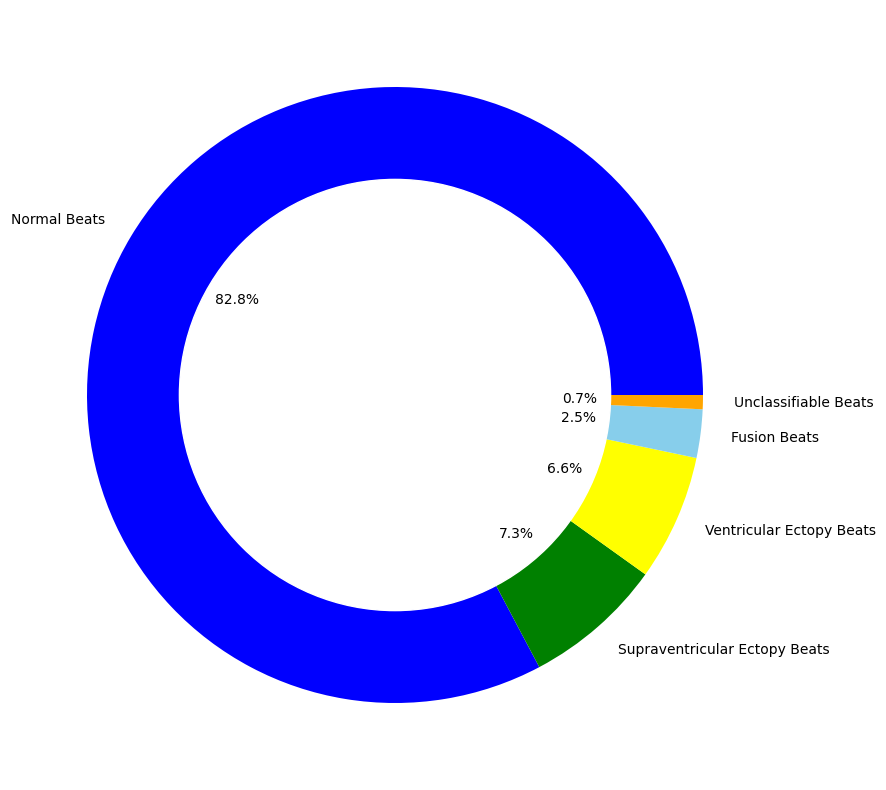

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
my_circle=plt.Circle( (0,0), 0.7, color='white')
plt.pie(equilibre, labels=['Normal Beats','Supraventricular Ectopy Beats','Ventricular Ectopy Beats','Fusion Beats','Unclassifiable Beats'], colors=['Blue','Green','Yellow','Skyblue','Orange'],autopct='%1.1f%%', textprops={'color': 'black'})
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.show()

In [9]:
from sklearn.utils import resample
#Resampling the train data
df_1 = train[train[187] == 1]
df_2 = train[train[187] == 2]
df_3 = train[train[187] == 3]
df_4 = train[train[187] == 4]

df_1_upsample = resample(df_1, n_samples=20000, replace=True, random_state=123)
df_2_upsample = resample(df_2, n_samples=20000, replace=True, random_state=123)
df_3_upsample = resample(df_3, n_samples=20000, replace=True, random_state=123)
df_4_upsample = resample(df_4, n_samples=20000, replace=True, random_state=123)
df_0 = train[train[187] == 0].sample(n=20000, random_state=123)

train = pd.concat([df_0, df_1_upsample, df_2_upsample, df_3_upsample, df_4_upsample])

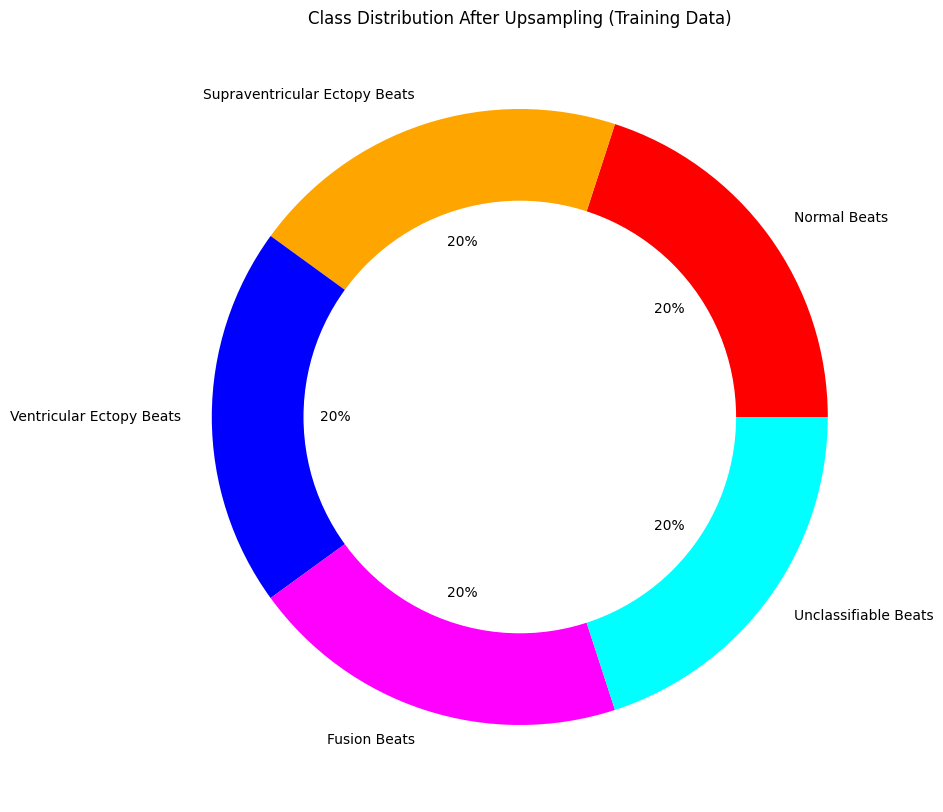

In [10]:
plt.figure(figsize=(10, 10))
my_circle = plt.Circle((0, 0), 0.7, color='white')
plt.pie(train[187].value_counts(), 
        labels=['Normal Beats', 'Supraventricular Ectopy Beats', 'Ventricular Ectopy Beats', 'Fusion Beats', 'Unclassifiable Beats'], 
        autopct='%0.0f%%', 
        colors=['red', 'orange', 'blue', 'magenta', 'cyan'])
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.title("Class Distribution After Upsampling (Training Data)")
plt.show()

In [11]:
#Resampling the test data

df_1_t = test[test[187] == 1]
df_2_t = test[test[187] == 2]
df_3_t = test[test[187] == 3]
df_4_t = test[test[187] == 4]

df_1_upsample_t = resample(df_1_t, n_samples=5000, replace=True, random_state=123)
df_2_upsample_t = resample(df_2_t, n_samples=5000, replace=True, random_state=123)
df_3_upsample_t = resample(df_3_t, n_samples=5000, replace=True, random_state=123)
df_4_upsample_t = resample(df_4_t, n_samples=5000, replace=True, random_state=123)
df_0_t = test[test[187] == 0].sample(n=5000, random_state=123)

test = pd.concat([df_0_t, df_1_upsample_t, df_2_upsample_t, df_3_upsample_t, df_4_upsample_t])

In [12]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]
X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [13]:
from scipy.signal import butter, filtfilt
import numpy as np
# applying low-pass filter to eliminate high-frequency noise
def butter_lowpass_filter(data, cutoff_freq, fs, order=5):
    nyquist_freq = 0.5 * fs
    normal_cutoff = cutoff_freq / nyquist_freq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return np.array([filtfilt(b, a, row) for row in data.values])

sampling_rate = 125  
cutoff_frequency = 50  
X_train_filtered = butter_lowpass_filter(X_train, cutoff_frequency, sampling_rate)
X_test_filtered = butter_lowpass_filter(X_test, cutoff_frequency, sampling_rate)


--- Model Evaluation ---
Confusion Matrix:
[[4955   18   16    3    8]
 [1311 3649   26    0   14]
 [ 264    2 4637   68   29]
 [ 941    0  537 3522    0]
 [ 180    7   22    0 4791]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.65      0.99      0.78      5000
         1.0       0.99      0.73      0.84      5000
         2.0       0.89      0.93      0.91      5000
         3.0       0.98      0.70      0.82      5000
         4.0       0.99      0.96      0.97      5000

    accuracy                           0.86     25000
   macro avg       0.90      0.86      0.86     25000
weighted avg       0.90      0.86      0.86     25000


Accuracy Score: 0.86216


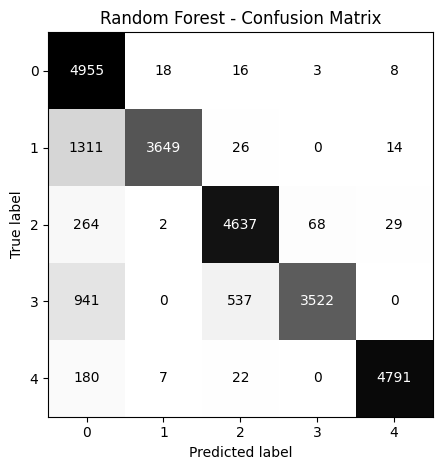

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_filtered, y_train)

y_pred = rf_model.predict(X_test_filtered)

print("\n--- Model Evaluation ---")
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d", cmap="Greys", colorbar=False)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()
